In [ ]:
# ── EXP-05: DeepLabV3 R101 + Focal Loss + Aug — Damage Classification ────────
data_dir    = 'xBD_UC3M'
patch_size  = 512
num_epochs  = 40
batch_size  = 2
num_workers = 0

BASE_RESULT_DIR = r'/Users/juan.macias@feverup.com/Desktop/cv/cv-2a-image-segmentation/VA_Pr2A_ImageSegmentation_2025_2026/results/parte-4'
result_dir      = os.path.join(BASE_RESULT_DIR, 'exp05_deeplabv3_multiclass')
model_name      = 'deeplabv3_multiclass_exp05'

# 5 classes: 0=background, 1=no-damage, 2=minor-damage, 3=major-damage, 4=destroyed
# mask_patch_raw: 255=background -> remap to 0; damage levels 0-3 -> remap to 1-4
num_classes = 5
class_names = ['background', 'no-damage', 'minor-damage', 'major-damage', 'destroyed']

if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')
print(f'Device: {device}')

_IMAGENET_MEAN = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
_IMAGENET_STD  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

train_ds_raw = xBDDataset(data_dir, split=['train'], task='segmentation',
                           patch_size=patch_size, stats=None, transform=None)
val_ds_raw   = xBDDataset(data_dir, split=['val'],   task='segmentation',
                           patch_size=patch_size, stats=None, transform=None)
test_ds_raw  = xBDDataset(data_dir, split=['test'],  task='segmentation',
                           patch_size=patch_size, stats=None, transform=None)


class KeyAdapterMulticlassAug(Dataset):
    def __init__(self, ds, augment=False):
        self.ds      = ds
        self.augment = augment

    def __len__(self):
        return len(self.ds)

    def __getitem__(self, idx):
        s     = self.ds[idx]
        image = (s['patch_post'].clone() - _IMAGENET_MEAN) / _IMAGENET_STD
        # mask_patch_raw: 255=background -> 0; damage 0-3 -> 1-4
        raw  = s['mask_patch_raw']
        mask = torch.where(raw == 255, torch.zeros_like(raw), raw + 1).long()

        if self.augment:
            if random.random() > 0.5:
                image = torch.flip(image, [2])
                mask  = torch.flip(mask,  [1])
            if random.random() > 0.5:
                image = torch.flip(image, [1])
                mask  = torch.flip(mask,  [0])
            k = random.randint(0, 3)
            if k:
                image = torch.rot90(image, k, [1, 2])
                mask  = torch.rot90(mask,  k, [0, 1])
            image = image + random.uniform(-0.1, 0.1)
            for c in range(image.shape[0]):
                mu = image[c].mean()
                image[c] = (image[c] - mu) * random.uniform(0.8, 1.2) + mu

        return {'image': image, 'mask': mask, 'img_path': s['patch_post_path']}


dataloaders = {
    'Train': DataLoader(KeyAdapterMulticlassAug(train_ds_raw, augment=True),  batch_size=batch_size,
                        shuffle=True,  num_workers=num_workers),
    'Val':   DataLoader(KeyAdapterMulticlassAug(val_ds_raw,   augment=False), batch_size=1,
                        shuffle=False, num_workers=num_workers),
    'Test':  DataLoader(KeyAdapterMulticlassAug(test_ds_raw,  augment=False), batch_size=1,
                        shuffle=False, num_workers=num_workers),
}


class FocalLoss(torch.nn.Module):
    def __init__(self, gamma=2.0, alpha=None):
        super().__init__()
        self.gamma = gamma
        self.alpha = alpha

    def forward(self, inputs, targets):
        ce    = torch.nn.functional.cross_entropy(inputs, targets,
                                                  weight=self.alpha, reduction='none')
        p_t   = torch.exp(-ce)
        focal = (1.0 - p_t) ** self.gamma * ce
        return focal.mean()


from torchvision.models.segmentation import deeplabv3_resnet101, DeepLabV3_ResNet101_Weights
from torchvision.models.segmentation.fcn import FCNHead

def get_deeplabv3_r101(num_classes):
    model = deeplabv3_resnet101(weights=DeepLabV3_ResNet101_Weights.DEFAULT)
    model.classifier     = DeepLabHead(2048, num_classes)
    model.aux_classifier = FCNHead(1024, num_classes)
    return model


def get_activations(model, dataloaders, device, result_dir, num_classes, class_names):
    """Visualize ASPP branch activations x class probability maps for each test image.

    Saves one figure per image to result_dir/activations/.
    Grid: rows = 4 ASPP branches (1x1, r=6, r=12, r=18),
          cols = input+branch overlay, then one column per class.
    Each cell (branch, class) shows branch activation weighted by class probability.
    """
    os.makedirs(os.path.join(result_dir, 'activations'), exist_ok=True)

    captured = {}
    def make_hook(key):
        def hook(m, inp, out):
            captured[key] = out.detach().cpu()
        return hook

    # model.classifier[0] = ASPP module inside DeepLabHead
    # convs[0]=1x1, convs[1..3]=atrous r=6,12,18, convs[4]=global avg pool
    aspp = model.classifier[0]
    branch_labels = ['1x1 (r=1)', 'atrous r=6', 'atrous r=12', 'atrous r=18']
    hooks = [aspp.convs[i].register_forward_hook(make_hook(i)) for i in range(4)]

    model.eval()
    with torch.no_grad():
        for sample in tqdm(dataloaders['Test']):
            inputs   = sample['image'].to(device)
            img_name = os.path.basename(sample['img_path'][0])

            probs = torch.softmax(model(inputs)['out'], dim=1).cpu()[0]  # (C, H, W)
            H, W  = inputs.shape[2:]

            img_vis = inputs[0].cpu().permute(1, 2, 0).numpy()
            img_vis = (img_vis - img_vis.min()) / (img_vis.max() - img_vis.min() + 1e-8)

            # Upsample mean-channel activation per ASPP branch to input resolution
            branch_maps = []
            for i in range(4):
                feat = captured[i][0].mean(dim=0)  # (h, w)
                up = torch.nn.functional.interpolate(
                    feat.unsqueeze(0).unsqueeze(0).float(),
                    size=(H, W), mode='bilinear', align_corners=False
                ).squeeze().numpy()
                mn, mx = up.min(), up.max()
                branch_maps.append((up - mn) / (mx - mn + 1e-8))

            n_cols = 1 + num_classes  # input+branch overlay + one per class
            fig, axes = plt.subplots(4, n_cols, figsize=(3 * n_cols, 12), squeeze=False)

            for ri, blabel in enumerate(branch_labels):
                axes[ri, 0].imshow(img_vis)
                axes[ri, 0].imshow(branch_maps[ri], cmap='hot', alpha=0.5)
                axes[ri, 0].set_ylabel(blabel, fontsize=8)
                axes[ri, 0].set_title('Input + branch' if ri == 0 else '', fontsize=8)
                axes[ri, 0].axis('off')

                for ci, cname in enumerate(class_names):
                    act = branch_maps[ri] * probs[ci].numpy()
                    axes[ri, ci + 1].imshow(act, cmap='hot', vmin=0)
                    axes[ri, ci + 1].set_title(cname if ri == 0 else '', fontsize=8)
                    axes[ri, ci + 1].axis('off')

            plt.suptitle(os.path.splitext(img_name)[0], fontsize=9)
            plt.tight_layout()
            plt.savefig(
                os.path.join(result_dir, 'activations', img_name[:-4] + '_act.png'),
                dpi=100, bbox_inches='tight'
            )
            plt.close(fig)

    for h in hooks:
        h.remove()
    print(f'Activation maps saved to {os.path.join(result_dir, "activations")}')


Device: mps

[xBDDataset] split=['train']  task=segmentation  patch_size=512  samples=254
  Building annotations across all windows:
    no-damage      :   13216
    minor-damage   :    1117
    major-damage   :     617
    destroyed      :     864
    unlabelled     :       0


[xBDDataset] split=['val']  task=segmentation  patch_size=512  samples=45
  Building annotations across all windows:
    no-damage      :    1314
    minor-damage   :     228
    major-damage   :     242
    destroyed      :     143
    unlabelled     :       0


[xBDDataset] split=['test']  task=segmentation  patch_size=512  samples=63
  Building annotations across all windows:
    no-damage      :    4957
    minor-damage   :     516
    major-damage   :     153
    destroyed      :     324
    unlabelled     :       0



Parameters: 60,987,978
Epoch 1/40
----------


100%|██████████| 127/127 [01:06<00:00,  1.91it/s]


Train Loss: 1.2724


100%|██████████| 45/45 [00:04<00:00, 10.52it/s]


Val Loss: 1.8080
{'epoch': 1, 'Train_loss': 1.2724220630690808, 'Val_loss': 1.8079751988252004, 'Train_jaccard_score': np.float64(0.03480545851433861), 'Val_jaccard_score': np.float64(0.0)}
Epoch 2/40
----------


...

Train Loss: 0.3504


100%|██████████| 45/45 [00:04<00:00, 10.44it/s]


Val Loss: 2.3340
{'epoch': 40, 'Train_loss': 0.3504272403092835, 'Val_loss': 2.3340051462252935, 'Train_jaccard_score': np.float64(0.35638559178365536), 'Val_jaccard_score': np.float64(0.3095832306039412)}
Training complete in 47m 51s
Highest Jaccard: 0.3174


/var/folders/_p/5w1h40jj05l3vm710fcfdtzr0000gq/T/ipykernel_17146/3159824807.py:27: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  weights = torch.load(os.path.join(result_dir

Jaccard index per class: [0.39540608 0.00065114 0.         0.00205418]


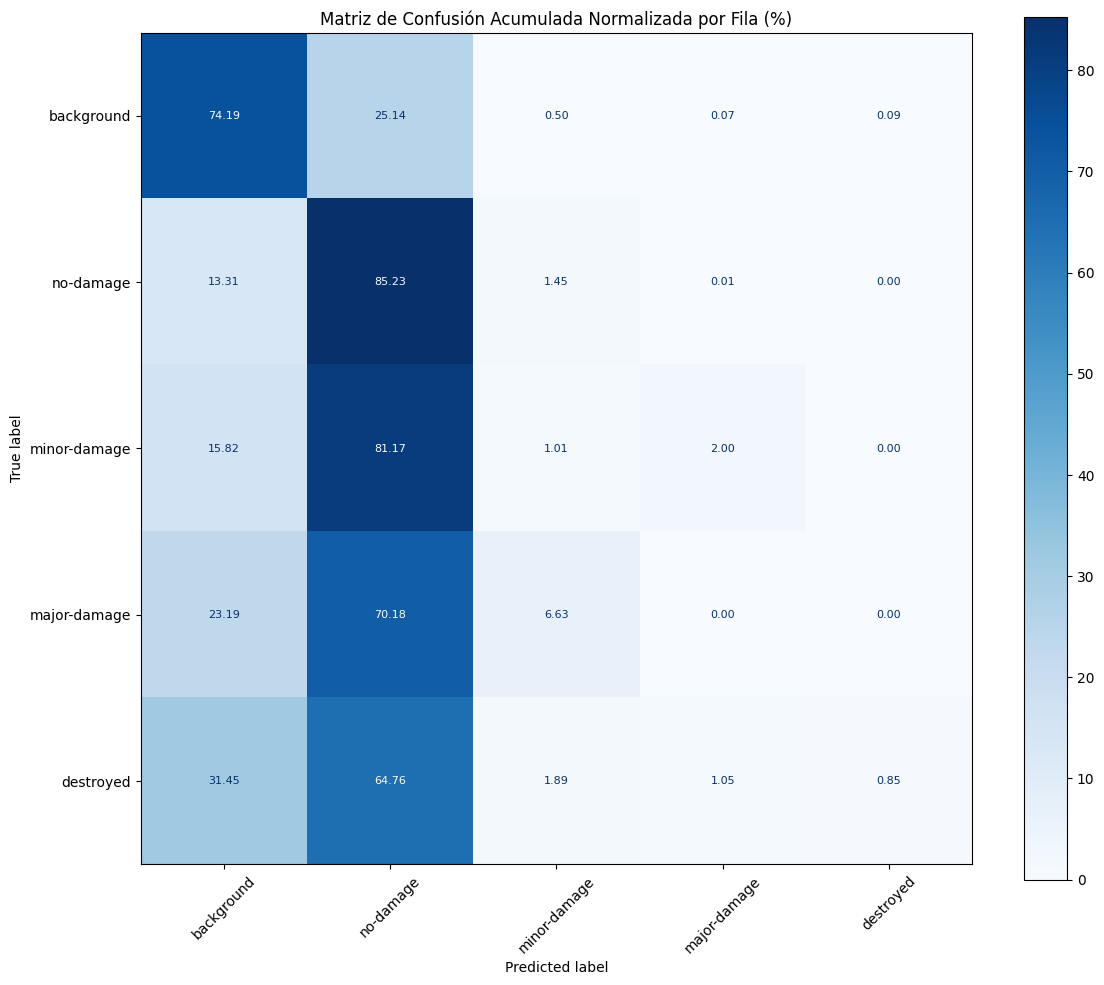

100%|██████████| 63/63 [00:49<00:00,  1.26it/s]

Activation maps saved to /Users/juan.macias@feverup.com/Desktop/cv/cv-2a-image-segmentation/VA_Pr2A_ImageSegmentation_2025_2026/results/parte-4/exp05_deeplabv3_multiclass/activations


In [ ]:
model = get_deeplabv3_r101(num_classes).to(device)
print(f'Parameters: {sum(p.numel() for p in model.parameters()):,}')

# Background ~82% of pixels; no-damage ~12%; minor/major/destroyed ~2% each
# class order: 0=background, 1=no-damage, 2=minor-damage, 3=major-damage, 4=destroyed
alpha     = torch.tensor([1.0, 4.0, 6.0, 6.0, 6.0]).to(device)
criterion = FocalLoss(gamma=2.0, alpha=alpha)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
# ReduceLROnPlateau monitors Val Jaccard and only decays when improvement stalls.
# This keeps the LR high while coarse features are learned and reduces it
# later when fine detail (e.g. building borders) is the remaining bottleneck.
lr_sched  = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.5, patience=4, min_lr=1e-7
)
metrics   = {'jaccard_score': jaccard_score}

os.makedirs(result_dir, exist_ok=True)

model = train_model(
    model, criterion, dataloaders, device,
    optimizer, lr_sched, metrics,
    result_dir, model_name,
    num_classes=num_classes, num_epochs=num_epochs,
)

weights = torch.load(os.path.join(result_dir, model_name + '_best.pth.tar'))['state_dict']
model.to(device)
model.load_state_dict(weights)
model.eval()
cm_total = test_segmentation_model(model, dataloaders, num_classes, class_names, result_dir, True, batchsize_test)

get_activations(model, dataloaders, device, result_dir, num_classes, class_names)
